#Deep Learning para visión de computadoras
##Lab 1.3 Arquitecturas CNN de referencia: LeNet-5, AlexNet, GoogLeNet y VGG16

**Unidad 1.** Fundamentos de visión por computadora y redes convolucionales
**1.3** Arquitecturas CNN para clasificación

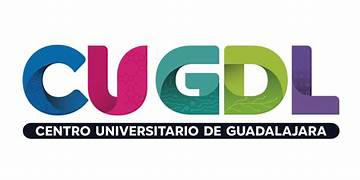

Esta práctica toma como referencia *"Arquitecturas de Redes Convolucionales"* (LeNet-5, AlexNet, GoogLeNet, VGG16), parte A definicion original de los modelos y parte B entrenamiento y evalúación sobre CIFAR-10, para poder comparar capacidad, número de parámetros, tiempo de entrenamiento y desempeño real.

**Objetivos de la práctica**
1. Implementar en PyTorch cuatro arquitecturas CNN clásicas adaptadas a CIFAR-10.
2. Entrenar y evaluar cada una bajo las mismas condiciones (mismos datos, épocas, optimizador).
3. Comparar número de parámetros, tiempo de entrenamiento y accuracy de test.
4. Discutir la relación entre profundidad/capacidad del modelo y su desempeño/eficiencia.

#PARTE A
### Arquitecturas de Redes Convolucionales
En el campo del deep learning y computer vision, una de estas competiciones, que hoy en día ya es un benchmark establecido, es la clasificación de imágenes en el dataset Imagenet. En 2012, la primera red neuronal convolucional entró en esta competición consiguiendo una mejora de 10 puntos sobre la mejor solución hasta la fecha, lo cual supuso un detonante para el campo del deep learning.

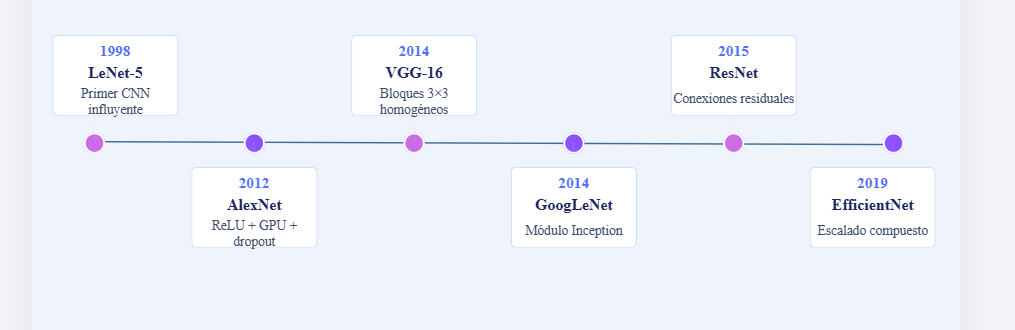

## LeNet-5

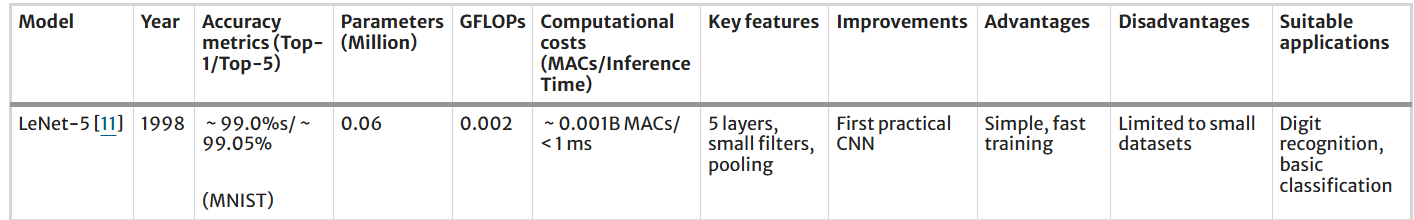

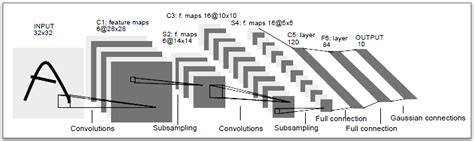

Esta `CNN` es alimentada por imágenes de 32x32 píxeles de dígitos manuscritos, y está formada por tres capas convolucionales, dos de las cuales reducen la dimensionalidad de los mapas de características mediante *average pooling*. La salida de la última capa convolucional es conectada un perceptrón multicapa de dos capas, que tienen la responsabilidad de dar la predicción final. [Artículo de publicación original](http://yann.lecun.com/exdb/publis/pdf/lecun-01a.pdf) . A continuación puedes ver un ejemplo de implementación en `Pytorch`.

In [1]:
import torch

def block(c_in, c_out, k=3, p=1, s=1):
    return torch.nn.Sequential(
        torch.nn.Conv2d(c_in, c_out, k, padding=p, stride=s),
        torch.nn.Tanh(),
        torch.nn.AvgPool2d(2, stride=2)
    )

def block2(c_in, c_out):
    return torch.nn.Sequential(
        torch.nn.Linear(c_in, c_out),
        torch.nn.ReLU()
    )

class LeNet5(torch.nn.Module):
  def __init__(self, n_channels=1, n_outputs=10):
    super().__init__()
    #self.pad = torch.nn.ConstantPad2d(2, 0.)
    self.conv1 = block(n_channels, 6, 5, p=0)
    self.conv2 = block(6, 16, 5, p=0)
    self.conv3 = torch.nn.Sequential(
        torch.nn.Conv2d(16, 120, 5, padding=0),
        torch.nn.Tanh()
    )
    self.fc1 = block2(120, 84)
    self.fc2 = torch.nn.Linear(84, 10)

  def forward(self, x):
    #x = self.pad(x)
    x = self.conv1(x)
    x = self.conv2(x)
    x = self.conv3(x)
    x = x.view(x.shape[0], -1)
    x = self.fc1(x)
    x = self.fc2(x)
    return x

## Actividad
### Ejercicio: rastreo de dimensiones en LeNet-5

Para una entrada `torch.randn(64, 1, 32, 32)`:

- **Entrada:** `(64, 1, 32, 32)`.
- **Conv1:** 6 filtros de `5×5`, stride `1`, padding `0` → `(64, 6, 28, 28)`.
- **AvgPool1:** filtro `2×2`, stride `2` → `(64, 6, 14, 14)`.
- **Conv2:** 16 filtros de `5×5`, stride `1`, padding `0` → `(64, 16, 10, 10)`.
- **AvgPool2:** filtro `2×2`, stride `2` → `(64, 16, 5, 5)`.
- **Conv3:** 120 filtros de `5×5`, stride `1`, padding `0` → `(64, 120, 1, 1)`.
- **Flatten:** `(64, 120)`.
- **FC1:** 84 neuronas → `(64, 84)`.
- **FC2:** 10 neuronas → `(64, 10)`.
- **Salida final:** `torch.Size([64, 10])`.

Se usa la fórmula:

$O = \left\lfloor \frac{N + 2P - F}{S} \right\rfloor + 1$

Ejemplo en Conv1: $O=(32+2(0)-5)/1+1=28$. Después, el pooling reduce `28×28` a `14×14`. El mismo procedimiento da `10×10`, `5×5` y finalmente `1×1` en Conv3.

Nota: en el código proporcionado no existe una tercera capa densa; `fc2` es la capa final de 10 clases.


In [2]:
lenet5 = LeNet5()
x = torch.randn(64, 1, 32, 32)

x1 = lenet5.conv1(x)
x2 = lenet5.conv2(x1)
x3 = lenet5.conv3(x2)
x_flat = x3.view(x3.shape[0], -1)
x_fc1 = lenet5.fc1(x_flat)
output = lenet5.fc2(x_fc1)

print("Entrada:  ", x.shape)
print("Bloque 1: ", x1.shape)
print("Bloque 2: ", x2.shape)
print("Conv3:    ", x3.shape)
print("Flatten:  ", x_flat.shape)
print("FC1:      ", x_fc1.shape)
print("Salida:   ", output.shape)


Entrada:   torch.Size([64, 1, 32, 32])
Bloque 1:  torch.Size([64, 6, 14, 14])
Bloque 2:  torch.Size([64, 16, 5, 5])
Conv3:     torch.Size([64, 120, 1, 1])
Flatten:   torch.Size([64, 120])
FC1:       torch.Size([64, 84])
Salida:    torch.Size([64, 10])


## AlexNet
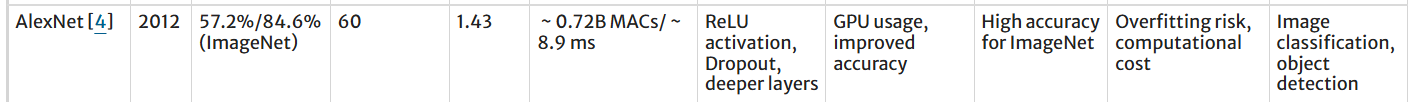



[AlexNet](https://papers.nips.cc/paper/4824-imagenet-classification-with-deep-convolutional-neural-networks.pdf) ganó la competición de Imagenet en 2012. Es una arquitectura similar a LeNet5 pero más profunda. Fue la primera red convolucional que ganó la competición, y también la primera en ser entrenada en GPUs.

![](https://miro.medium.com/fit/c/1838/551/1*arJJYgK-_7VcuKKX1TCKMA.png)

Implementadas en `Pytorch` podemos descargar redes convolucionales con el paquete `torchvision` (en varios paquetes) .

In [3]:
import torchvision
alexnet = torchvision.models.alexnet(weights=None)
alexnet


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

## Actividad: AlexNet

La entrada `torch.randn(64, 3, 224, 224)` representa un lote de **64 imágenes RGB**, con **3 canales** y dimensiones de **224×224 píxeles**.

La salida tiene forma `(64, 1000)` porque AlexNet está configurada por defecto para ImageNet, que contiene 1000 clases. Esto se observa en la última capa del clasificador: `alexnet.classifier[6]`, que es `Linear(in_features=4096, out_features=1000)`. Cada fila de la salida contiene 1000 puntuaciones, una por clase.


In [4]:
# El dispositivo meta calcula las formas sin reservar memoria para las imágenes.
alexnet = alexnet.to("meta")
output = alexnet(torch.empty(64, 3, 224, 224, device="meta"))

print("Entrada: torch.Size([64, 3, 224, 224])")
print("Última capa:", alexnet.classifier[6])
print("Salida:", output.shape)


Entrada: torch.Size([64, 3, 224, 224])
Última capa: Linear(in_features=4096, out_features=1000, bias=True)
Salida: torch.Size([64, 1000])


## VGG
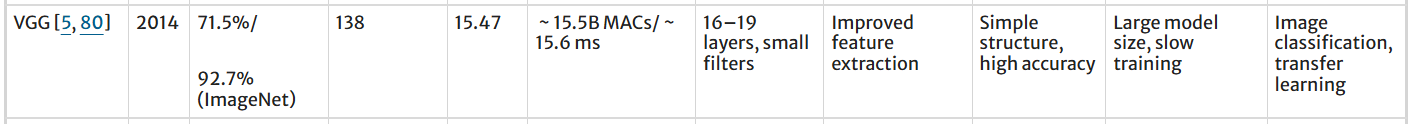



Si bien [VGG](https://arxiv.org/abs/1409.1556) no ganó, tuvo mucho éxito ya que sentó un precedente en el patrón del diseño de las redes convolucionales. Este patrón consiste en usar siempre capas convolucionales con filtros de 3x3, *stride* y *padding* 1 (manteniendo el tamaño de las entradas constante) y usar *max pool* para reducir a la mitad los mapas de características. Además, después de cada capa se dobla el número de filtros.

![](http://jesusutrera.com/articles/img/vgg_model.png)

In [5]:
vgg16 = torchvision.models.vgg16(weights=None)
vgg16


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [6]:
# Se usa meta para comprobar la forma sin almacenar un lote grande en memoria.
vgg16 = vgg16.to("meta")
output = vgg16(torch.empty(64, 3, 224, 224, device="meta"))
print("Salida de VGG16:", output.shape)


Salida de VGG16: torch.Size([64, 1000])


## Actividad: modelos VGG

`torchvision.models` incluye **8 variantes VGG**: VGG11, VGG13, VGG16 y VGG19, cada una con una versión normal y otra con Batch Normalization (`_bn`). El número indica la profundidad aproximada de la red; las variantes `_bn` agregan BatchNorm después de las convoluciones.


In [7]:
modelos_vgg = {
    "vgg11": torchvision.models.vgg11,
    "vgg11_bn": torchvision.models.vgg11_bn,
    "vgg13": torchvision.models.vgg13,
    "vgg13_bn": torchvision.models.vgg13_bn,
    "vgg16": torchvision.models.vgg16,
    "vgg16_bn": torchvision.models.vgg16_bn,
    "vgg19": torchvision.models.vgg19,
    "vgg19_bn": torchvision.models.vgg19_bn,
}

print(f"Cantidad de modelos VGG definidos: {len(modelos_vgg)}")
for nombre in modelos_vgg:
    print("-", nombre)


Cantidad de modelos VGG definidos: 8
- vgg11
- vgg11_bn
- vgg13
- vgg13_bn
- vgg16
- vgg16_bn
- vgg19
- vgg19_bn


## GoogLeNet
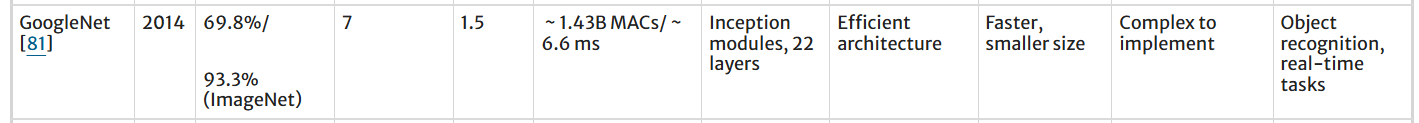



Ganadora de la edición de 2014, GoogLeNet es una red mucho más profunda (podemos empezar a ver la tendencia de que cuantas más capas, mejor resultados). Sus desarrolladores implementaron los módulos *inception*, los cuales aplican diferentes capas convolucionales, con diferentes tamaños de filtros, en paralelo sobre las mismas entradas y luego concatenan las salidas. Además, para poder entrenar esta red tan profunda, se llevan a cabo predicciones en diversas capas intermedias para poder tener gradientes fluyendo hacia las capas iniciales.

![](https://www.alanzucconi.com/wp-content/uploads/2015/07/googlenet-arch.png)

In [8]:
googlenet = torchvision.models.googlenet(weights=None, aux_logits=False, init_weights=False)
googlenet


GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001,

In [9]:
# Se usa meta para comprobar la forma sin almacenar un lote grande en memoria.
googlenet = googlenet.to("meta")
output = googlenet(torch.empty(64, 3, 224, 224, device="meta"))
print("Salida de GoogLeNet:", output.shape)


Salida de GoogLeNet: torch.Size([64, 1000])


## Actividad: GoogLeNet e Inception

- La GoogLeNet original contiene **9 bloques Inception**: `3a`, `3b`, `4a`, `4b`, `4c`, `4d`, `4e`, `5a` y `5b`.
- Cada bloque procesa la entrada mediante **4 ramas paralelas**: convolución `1×1`; reducción `1×1` seguida de `3×3`; reducción `1×1` seguida de otra convolución de mayor campo receptivo; y max pooling seguido de `1×1`.
- Antes del clasificador se usa **Global Average Pooling**, implementado como `AdaptiveAvgPool2d((1, 1))`. Esta capa resume cada mapa de características en un solo valor y evita conectar un vector espacial enorme a capas densas. Por ello reduce considerablemente el número de parámetros frente al Flatten usado por AlexNet o VGG.

La siguiente celda confirma los nueve bloques y dibuja un esquema sencillo del módulo Inception.


Bloques Inception: ['inception3a', 'inception3b', 'inception4a', 'inception4b', 'inception4c', 'inception4d', 'inception4e', 'inception5a', 'inception5b']
Total: 9
Pooling global: AdaptiveAvgPool2d(output_size=(1, 1))


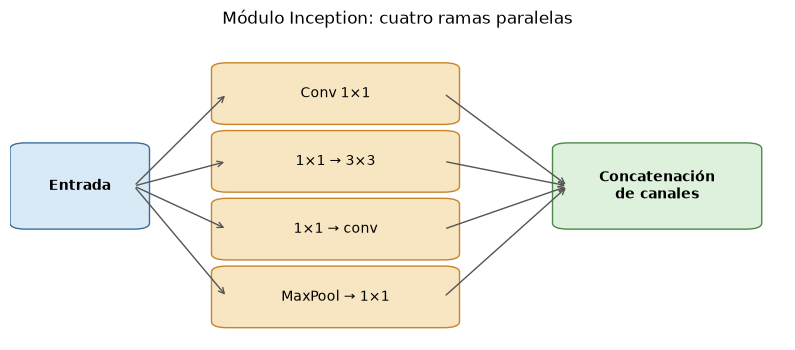

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

bloques_inception = [
    nombre for nombre, modulo in googlenet.named_children()
    if nombre.startswith("inception")
]
print("Bloques Inception:", bloques_inception)
print("Total:", len(bloques_inception))
print("Pooling global:", googlenet.avgpool)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")

ax.add_patch(FancyBboxPatch((0.02, 0.38), 0.14, 0.24, boxstyle="round,pad=0.02",
                            facecolor="#D9EAF7", edgecolor="#3E6D9C"))
ax.text(0.09, 0.50, "Entrada", ha="center", va="center", fontweight="bold")

ramas = ["Conv 1×1", "1×1 → 3×3", "1×1 → conv", "MaxPool → 1×1"]
y_pos = [0.80, 0.58, 0.36, 0.14]
for y, texto in zip(y_pos, ramas):
    ax.annotate("", xy=(0.28, y), xytext=(0.16, 0.50),
                arrowprops=dict(arrowstyle="->", color="#555555"))
    ax.add_patch(FancyBboxPatch((0.28, y-0.08), 0.28, 0.16, boxstyle="round,pad=0.02",
                                facecolor="#F8E5C2", edgecolor="#C9832B"))
    ax.text(0.42, y, texto, ha="center", va="center")
    ax.annotate("", xy=(0.72, 0.50), xytext=(0.56, y),
                arrowprops=dict(arrowstyle="->", color="#555555"))

ax.add_patch(FancyBboxPatch((0.72, 0.38), 0.23, 0.24, boxstyle="round,pad=0.02",
                            facecolor="#DDF1DD", edgecolor="#4C8A4C"))
ax.text(0.835, 0.50, "Concatenación\nde canales", ha="center", va="center", fontweight="bold")
ax.set_title("Módulo Inception: cuatro ramas paralelas")
plt.show()


#PARTE B
**Ajustes respecto a las arquitecturas originales:** las versiones originales de AlexNet y VGG16 fueron diseñadas para imágenes de 224×224 (ImageNet). Entrenarlas tal cual sobre CIFAR-10 (32×32) o reescalando cada imagen a 224×224 sería demasiado costoso. Por eso cada arquitectura se **adapta** aquí para trabajar directamente sobre 32×32 px, manteniendo su estructura conceptual (número y tipo de bloques, filtros, profundidad relativa) pero con canales/strides ajustados. Esto es intencional: la comparación de "capacidad versus eficiencia"

> 💡El dataset Imagenet contiene imágenes comunes descargadas de internet, y el objetivo es el de clasificar imágenes entre 1000 clases diferentes. Es por este motivo que verás que los diferentes modelos en `torchvision` tienen una última capa lineal con 1000 salidas.

## 1. Configuración e importaciones

In [11]:
import time
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import pandas as pd

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")


Dispositivo: cuda


## 2. Carga y preprocesamiento de CIFAR-10

Se usa CIFAR-10 (60,000 imágenes de 32×32 px a color, 10 clases) tal como indica el programa de la asignatura. Se separa un subconjunto de validación a partir del set de entrenamiento.

In [12]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

full_train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
test_set = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)

val_fraction = 0.1
val_size = int(len(full_train_set) * val_fraction)
train_size = len(full_train_set) - val_size
train_set, val_set = random_split(full_train_set, [train_size, val_size], generator=torch.Generator().manual_seed(42))

BATCH_SIZE = 128
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

classes = ("avión", "automóvil", "pájaro", "gato", "venado", "perro", "rana", "caballo", "barco", "camión")
print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")


Train: 45000 | Val: 5000 | Test: 10000


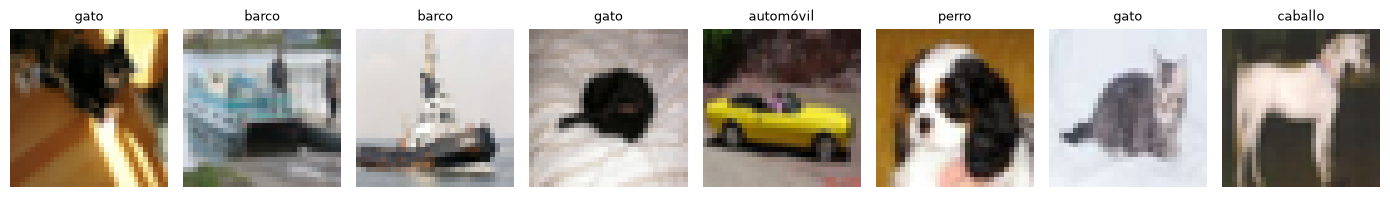

In [13]:
# Vista rápida de algunas imágenes del dataset
def imshow(img):
    img = img * torch.tensor([0.2470, 0.2435, 0.2616]).view(3,1,1) + torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    npimg = img.numpy()
    plt.imshow(npimg.transpose(1, 2, 0).clip(0, 1))

sample_loader = DataLoader(test_set, batch_size=8, shuffle=True)
images, labels = next(iter(sample_loader))
fig, axes = plt.subplots(1, 8, figsize=(14, 2))
for i, ax in enumerate(axes):
    ax.imshow((images[i] * torch.tensor([0.2470,0.2435,0.2616]).view(3,1,1) + torch.tensor([0.4914,0.4822,0.4465]).view(3,1,1)).permute(1,2,0).clip(0,1))
    ax.set_title(classes[labels[i]], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Arquitecturas

Se implementan cuatro arquitecturas, cada una en su propia celda, con un breve comentario sobre su idea central y el ajuste realizado para CIFAR-10.

### 3.1 LeNet-5 (LeCun et al., 1998)

## Actividad resuelta

La LeNet-5 original recibe imágenes de un solo canal, mientras que la versión adaptada recibe las tres bandas RGB de CIFAR-10. La primera convolución usa padding para conservar inicialmente el tamaño de `32×32`. Después se mantienen dos convoluciones, activaciones Tanh y average pooling, pero el clasificador se ajusta al tensor de `16×6×6`. La salida continúa teniendo 10 neuronas porque CIFAR-10 también tiene 10 clases.


In [14]:
class LeNet5(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 6, kernel_size=5, padding=2),   # 32x32 -> 32x32
            nn.Tanh(),
            nn.AvgPool2d(2),                              # -> 16x16
            nn.Conv2d(6, 16, kernel_size=5),               # -> 12x12
            nn.Tanh(),
            nn.AvgPool2d(2),                               # -> 6x6
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 6 * 6, 120), nn.Tanh(),
            nn.Linear(120, 84), nn.Tanh(),
            nn.Linear(84, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


### 3.2 AlexNet adaptado (Krizhevsky et al., 2012)

## Actividad resuelta

La AlexNet original trabaja con imágenes de aproximadamente `224×224`, comienza con una convolución grande de `11×11` y utiliza capas densas de 4096 neuronas para clasificar 1000 categorías de ImageNet. La adaptación recibe imágenes de `32×32`, usa convoluciones `3×3`, conserva la idea de cinco capas convolucionales y dropout, pero reduce las capas densas a 1024 y 512 neuronas. La salida se cambia de 1000 a 10 clases para CIFAR-10.


In [15]:
class AlexNetAdaptado(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                        # -> 16x16
            nn.Conv2d(64, 192, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                        # -> 8x8
            nn.Conv2d(192, 384, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                        # -> 4x4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 4 * 4, 1024), nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(1024, 512), nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


### 3.3 VGG16 adaptado (Simonyan & Zisserman, 2014)

## Actividad resuelta

La VGG16 original procesa imágenes de `224×224`, alcanza hasta 512 canales y termina con capas densas de 4096 neuronas para 1000 clases. La versión adaptada conserva el patrón característico de convoluciones `3×3` y max pooling, pero empieza con 32 canales, llega como máximo a 256 y reduce el clasificador a una capa de 512 neuronas. Estos cambios disminuyen el costo para imágenes CIFAR-10 de `32×32` y producen 10 salidas.


In [16]:
class VGGBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_convs):
        super().__init__()
        layers = []
        for i in range(num_convs):
            in_c = in_channels if i == 0 else out_channels
            layers += [nn.Conv2d(in_c, out_channels, kernel_size=3, padding=1), nn.ReLU(inplace=True)]
        layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class VGG16Adaptado(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            VGGBlock(3, 32, 2),     # 32x32 -> 16x16
            VGGBlock(32, 64, 2),    # -> 8x8
            VGGBlock(64, 128, 3),   # -> 4x4
            VGGBlock(128, 256, 3),  # -> 2x2
            VGGBlock(256, 256, 3),  # -> 1x1
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 1 * 1, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


### 3.4 GoogLeNet mini (Szegedy et al., 2014)

## Actividad resuelta

La GoogLeNet original contiene nueve módulos Inception, clasificadores auxiliares y fue diseñada para ImageNet. La versión mini conserva las cuatro ramas paralelas de Inception y el global average pooling, pero utiliza solamente tres bloques Inception, un stem sencillo para imágenes de `32×32`, menos canales y ningún clasificador auxiliar. Su capa final tiene 10 salidas en lugar de 1000, por lo que requiere muchos menos parámetros y tiempo de entrenamiento.


In [17]:
class InceptionBlock(nn.Module):
    def __init__(self, in_channels, ch1x1, ch3x3red, ch3x3, ch5x5red, ch5x5, pool_proj):
        super().__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, ch1x1, kernel_size=1), nn.ReLU(inplace=True))
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, ch3x3red, kernel_size=1), nn.ReLU(inplace=True),
            nn.Conv2d(ch3x3red, ch3x3, kernel_size=3, padding=1), nn.ReLU(inplace=True))
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, ch5x5red, kernel_size=1), nn.ReLU(inplace=True),
            nn.Conv2d(ch5x5red, ch5x5, kernel_size=5, padding=2), nn.ReLU(inplace=True))
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, kernel_size=1), nn.ReLU(inplace=True))

    def forward(self, x):
        return torch.cat([self.branch1(x), self.branch2(x), self.branch3(x), self.branch4(x)], dim=1)


class GoogLeNetMini(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1), nn.ReLU(inplace=True),
            nn.MaxPool2d(2),                                    # -> 16x16
        )
        self.inception1 = InceptionBlock(64, 32, 32, 64, 8, 16, 16)     # out = 128
        self.inception2 = InceptionBlock(128, 64, 64, 96, 16, 32, 32)   # out = 224
        self.pool = nn.MaxPool2d(2)                                     # -> 8x8
        self.inception3 = InceptionBlock(224, 96, 64, 128, 16, 32, 32)  # out = 288
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.4), nn.Linear(288, num_classes))

    def forward(self, x):
        x = self.stem(x)
        x = self.inception1(x)
        x = self.inception2(x)
        x = self.pool(x)
        x = self.inception3(x)
        x = self.global_pool(x)
        return self.classifier(x)


## 4. Funciones genéricas de entrenamiento y evaluación

Las mismas funciones se usan para las cuatro arquitecturas, para que la comparación final sea justa.

## Actividad resuelta: hiperparámetros

- Tamaño de lote: `128`.
- Épocas: `5`.
- Learning rate: `0.001`.
- Función de pérdida: `CrossEntropyLoss`.
- Optimizador: `Adam`.
- Aumento de datos: recorte aleatorio y volteo horizontal.

Todos los modelos usan estos mismos valores para que la comparación sea directa.


In [18]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def train_model(model, train_loader, val_loader, epochs=8, lr=1e-3, name="modelo"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    start = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                v_loss += loss.item() * x.size(0)
                v_correct += (out.argmax(1) == y).sum().item()
                v_total += x.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"[{name}] Época {epoch+1}/{epochs} - "
              f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    elapsed = time.time() - start
    print(f"[{name}] Tiempo total de entrenamiento: {elapsed:.1f} s")
    return history, elapsed


def evaluate_test(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            correct += (out.argmax(1) == y).sum().item()
            total += x.size(0)
    return correct / total


## 5. Entrenamiento de las cuatro arquitecturas

`EPOCHS` Una buena práctica es configurar un bajo numero. Si el tiempo lo permite, se puede subir a 15–20 épocas para ver mejor las diferencias de convergencia.

In [19]:
EPOCHS = 5
LEARNING_RATE = 1e-3

modelos = {
    "LeNet-5": LeNet5(),
    "AlexNet (adaptado)": AlexNetAdaptado(),
    "GoogLeNet (mini)": GoogLeNetMini(),
    "VGG16 (adaptado)": VGG16Adaptado(),
}

historiales = {}
resultados = {}

for nombre, modelo in modelos.items():
    print(f"\n=== Entrenando {nombre} ===")
    n_params = count_params(modelo)
    print(f"Parámetros entrenables: {n_params:,}")
    hist, tiempo = train_model(modelo, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE, name=nombre)
    test_acc = evaluate_test(modelo, test_loader)
    print(f"[{nombre}] Accuracy en test: {test_acc:.4f}")

    historiales[nombre] = hist
    resultados[nombre] = {
        "parametros": n_params,
        "tiempo_entrenamiento_s": round(tiempo, 1),
        "val_acc_final": round(hist["val_acc"][-1], 4),
        "test_accuracy": round(test_acc, 4),
    }



=== Entrenando LeNet-5 ===
Parámetros entrenables: 83,126


[LeNet-5] Época 1/5 - train_loss=1.8714 train_acc=0.3272 val_loss=1.7642 val_acc=0.3746


[LeNet-5] Época 2/5 - train_loss=1.6737 train_acc=0.3981 val_loss=1.6264 val_acc=0.4150


[LeNet-5] Época 3/5 - train_loss=1.5595 train_acc=0.4374 val_loss=1.5236 val_acc=0.4568


[LeNet-5] Época 4/5 - train_loss=1.4913 train_acc=0.4592 val_loss=1.4632 val_acc=0.4682


...

[VGG16 (adaptado)] Época 2/5 - train_loss=1.8473 train_acc=0.2426 val_loss=1.7762 val_acc=0.2802


[VGG16 (adaptado)] Época 3/5 - train_loss=1.7540 train_acc=0.2997 val_loss=1.6580 val_acc=0.3610


[VGG16 (adaptado)] Época 4/5 - train_loss=1.5419 train_acc=0.3978 val_loss=1.4350 val_acc=0.4348


[VGG16 (adaptado)] Época 5/5 - train_loss=1.3883 train_acc=0.4596 val_loss=1.3671 val_acc=0.4710
[VGG16 (adaptado)] Tiempo total de entrenamiento: 27.2 s


[VGG16 (adaptado)] Accuracy en test: 0.4750


## 6. Comparación de resultados

In [20]:
df_resultados = pd.DataFrame(resultados).T
df_resultados = df_resultados.sort_values("test_accuracy", ascending=False)
df_resultados


,parametros,tiempo_entrenamiento_s,val_acc_final,test_accuracy
AlexNet (adaptado),6976842.0,38.3,0.6868,0.7047
GoogLeNet (mini),256530.0,28.3,0.5842,0.5789
LeNet-5,83126.0,15.7,0.4636,0.5060
VGG16 (adaptado),3816874.0,27.2,0.4710,0.4750


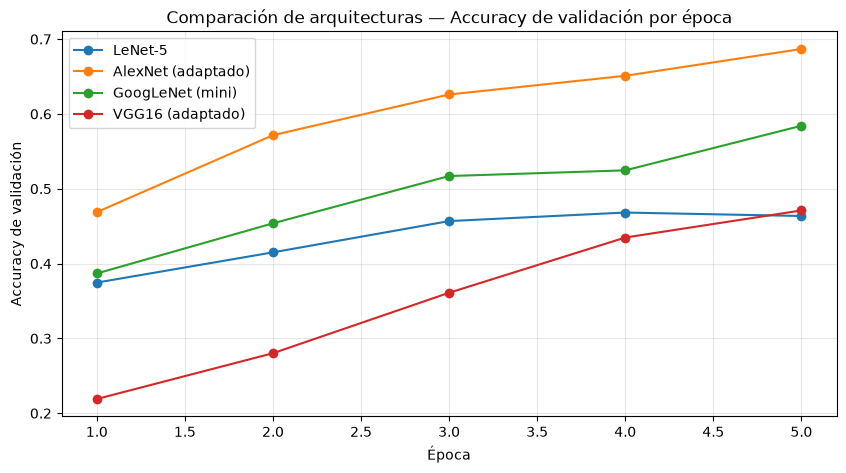

In [21]:
plt.figure(figsize=(10, 5))
for nombre, hist in historiales.items():
    plt.plot(range(1, EPOCHS + 1), hist["val_acc"], marker="o", label=nombre)
plt.xlabel("Época")
plt.ylabel("Accuracy de validación")
plt.title("Comparación de arquitecturas — Accuracy de validación por época")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


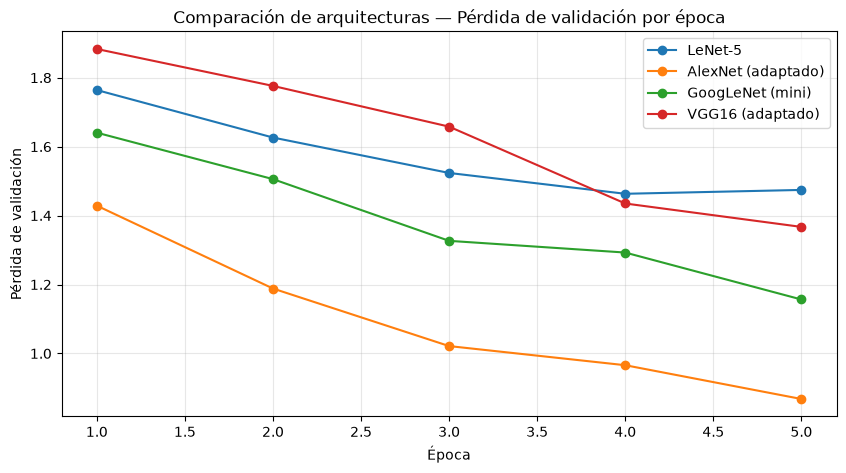

In [22]:
plt.figure(figsize=(10, 5))
for nombre, hist in historiales.items():
    plt.plot(range(1, EPOCHS + 1), hist["val_loss"], marker="o", label=nombre)
plt.xlabel("Época")
plt.ylabel("Pérdida de validación")
plt.title("Comparación de arquitecturas — Pérdida de validación por época")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


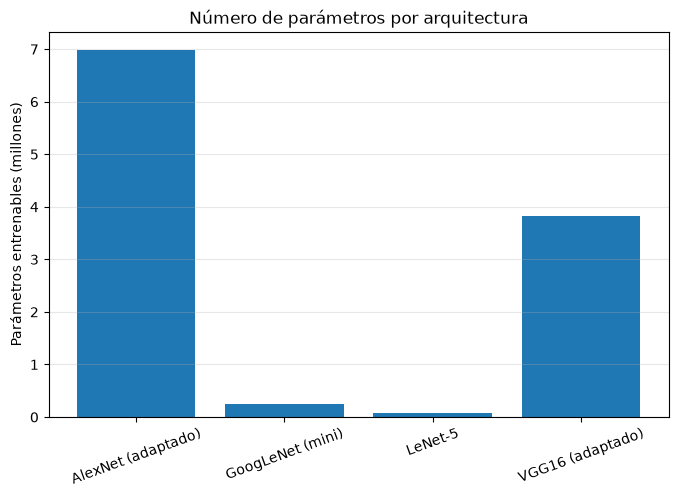

In [23]:
plt.figure(figsize=(8, 5))
plt.bar(df_resultados.index, df_resultados["parametros"] / 1e6)
plt.ylabel("Parámetros entrenables (millones)")
plt.title("Número de parámetros por arquitectura")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.show()


## 7. Preguntas de reflexión

1. ¿Qué arquitectura obtuvo el mejor accuracy de test? ¿Es también la que más parámetros tiene o la más rápida de entrenar?
2. Compara LeNet-5 contra las otras tres: ¿qué tanto mejora el accuracy al aumentar la profundidad/capacidad del modelo, y a qué costo?
3. ¿La diferencia de diseño de GoogLeNet mini se refleja en los resultados?
4. ¿Qué modelo elegirías para un dispositivo con recursos limitados y por qué?
5. ¿Qué esperarías si se entrenaran las cuatro arquitecturas durante 30 épocas?


### Respuestas

1. **Mejor accuracy de test.** AlexNet adaptado obtuvo el mejor resultado con `0.7047`. También fue el modelo con más parámetros (`6,976,842`) y el más lento de los cuatro (`38.3 s`), por lo que su mejor precisión tuvo un costo mayor de memoria y tiempo.

2. **LeNet-5 frente a los otros modelos.** LeNet-5 obtuvo `0.5060` de accuracy, usó solamente `83,126` parámetros y entrenó en `15.7 s`. AlexNet mejoró el accuracy en aproximadamente `0.1987`, pero utilizó alrededor de 84 veces más parámetros. GoogLeNet mini también mejoró a `0.5789` con solo `256,530` parámetros. VGG16 obtuvo `0.4750` en estas cinco épocas; su mayor profundidad no produjo una mejora inmediata porque necesita más entrenamiento y un ajuste más cuidadoso.

3. **Efecto del diseño Inception.** Sí se observa una buena relación entre capacidad y eficiencia. GoogLeNet mini consiguió el segundo mejor accuracy (`0.5789`) usando muchos menos parámetros que AlexNet y VGG16. Sus ramas paralelas extraen características de distintos tamaños sin depender de capas densas enormes.

4. **Modelo para un dispositivo limitado.** Elegiría GoogLeNet mini como equilibrio entre desempeño y tamaño: tiene `256,530` parámetros y supera a LeNet-5 en accuracy. Si la memoria y el tiempo fueran extremadamente limitados, LeNet-5 sería la opción más ligera y rápida.

5. **Entrenamiento durante 30 épocas.** Se espera que todos mejoren, especialmente VGG16 y GoogLeNet mini, que probablemente todavía no convergieron en cinco épocas. Sin embargo, después de cierto punto podría aparecer overfitting. Sería conveniente observar las curvas de validación, reducir el learning rate y detener el entrenamiento cuando la pérdida de validación deje de mejorar. El orden de los modelos podría cambiar, por lo que no se debe concluir que VGG16 es peor usando únicamente cinco épocas.


## 8. Entrega

Subir este notebook ejecutado, con las salidas visibles, a un repositorio público de GitHub dentro de la carpeta del curso y la subcarpeta `Unidad 1/Práctica 3`.

También se debe exportar el notebook a PDF, subir el PDF a Classroom y anexar el enlace del repositorio.
